In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 1) SUBIDA de archivos y organización local (Prioriza XLSX)   ║
# ╚════════════════════════════════════════════════════════════╝
import os
import shutil
import logging
import glob
from google.colab import files # ignóralo fuera de Colab

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# --- Nombres base esperados para los archivos O*NET (sin extensión) ---
# Estos nombres coinciden con los archivos que se suelen descargar.
ONET_BASE_NAMES = {
    "Abilities",
    "Skills",
    "Work Activities",
    "Work Context"
}
OEWS_EXPECTED_NAME = "national_m2024_dl.xlsx" # O el nombre exacto que uses

# pide los 5 ficheros
print(f"⬆️  Selecciona los archivos O*NET ({len(ONET_BASE_NAMES)} archivos, preferiblemente .xlsx) y el archivo OEWS Excel ({OEWS_EXPECTED_NAME})…")
uploaded = files.upload()      # ▸ espera selección

# carpetas destino
os.makedirs("data/onet", exist_ok=True)
os.makedirs("data/oews", exist_ok=True)

uploaded_onet_files = set()

# mueve cada archivo al lugar correcto
for name, blob in uploaded.items():
    processed = False
    # Verificar si es un archivo O*NET esperado (XLSX o TXT)
    for onet_base in ONET_BASE_NAMES:
        # Comprobar si el nombre del archivo subido comienza con un nombre base de O*NET
        # y termina con .xlsx o .txt
        if name.lower().startswith(onet_base.lower()):
            if name.lower().endswith(".xlsx"):
                # Priorizar XLSX: si ya subimos un TXT con el mismo base_name, lo reemplazamos si este es XLSX
                existing_txt_path = f"data/onet/{onet_base}.txt"
                if os.path.exists(existing_txt_path):
                    logging.info(f"Reemplazando {onet_base}.txt con {name} (XLSX).")
                    os.remove(existing_txt_path)
                    uploaded_onet_files.discard(f"{onet_base}.txt") # Quitar de los subidos si estaba

                target_path = f"data/onet/{onet_base}.xlsx" # Guardar con nombre base + .xlsx
                with open(target_path, "wb") as f: f.write(blob)
                logging.info(f"O*NET ✓ {onet_base}.xlsx (desde {name})")
                uploaded_onet_files.add(f"{onet_base}.xlsx")
                processed = True
                break
            elif name.lower().endswith(".txt"):
                # Solo guardar TXT si no hay ya un XLSX con el mismo base_name
                if not os.path.exists(f"data/onet/{onet_base}.xlsx"):
                    target_path = f"data/onet/{onet_base}.txt" # Guardar con nombre base + .txt
                    with open(target_path, "wb") as f: f.write(blob)
                    logging.info(f"O*NET ✓ {onet_base}.txt (desde {name})")
                    uploaded_onet_files.add(f"{onet_base}.txt")
                else:
                    logging.info(f"Ignorando {name} (TXT) porque ya existe {onet_base}.xlsx.")
                processed = True
                break

    if processed:
        continue

    # Verificar si es el archivo OEWS esperado
    if name.lower() == OEWS_EXPECTED_NAME.lower():
        with open(f"data/oews/{OEWS_EXPECTED_NAME}", "wb") as f: f.write(blob)
        logging.info(f"OEWS  ✓ {OEWS_EXPECTED_NAME}")
        processed = True

    if not processed:
        logging.warning(f"Archivo ignorado (no coincide con O*NET esperado ni OEWS): {name}")

# --- Verificación de archivos O*NET ---
# Ahora verificamos que para cada ONET_BASE_NAME, tengamos o un .xlsx o un .txt
missing_onet_bases = []
actual_onet_files_in_folder = []

for onet_base in ONET_BASE_NAMES:
    if os.path.exists(f"data/onet/{onet_base}.xlsx"):
        actual_onet_files_in_folder.append(f"{onet_base}.xlsx")
    elif os.path.exists(f"data/onet/{onet_base}.txt"):
        actual_onet_files_in_folder.append(f"{onet_base}.txt")
    else:
        missing_onet_bases.append(onet_base)

if missing_onet_bases:
    raise AssertionError(f"Faltan archivos O*NET para las siguientes bases: {missing_onet_bases}. Archivos encontrados en data/onet/: {actual_onet_files_in_folder}")
else:
    logging.info(f"Archivos O*NET verificados en data/onet/: {actual_onet_files_in_folder}")

# --- Verificación de archivo OEWS ---
assert os.path.exists(f"data/oews/{OEWS_EXPECTED_NAME}"), f"Falta el archivo OEWS: data/oews/{OEWS_EXPECTED_NAME}"

print("✅ Archivos listos y organizados.")


⬆️  Selecciona los archivos O*NET (4 archivos, preferiblemente .xlsx) y el archivo OEWS Excel (national_m2024_dl.xlsx)…


AssertionError: Faltan archivos O*NET para las siguientes bases: ['Abilities', 'Skills', 'Work Activities', 'Work Context']. Archivos encontrados en data/onet/: []

In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 2) OEWS 2024  –  LIMPIEZA                                   ║
# ╚════════════════════════════════════════════════════════════╝
import pandas as pd, re, logging
pd.set_option("display.max_columns", 120)

oews_raw = pd.read_excel(f"data/oews/{OEWS_EXPECTED_NAME}")

# normaliza headers
oews_raw.columns = (oews_raw.columns.str.strip().str.lower()
                    .str.replace(" ","_",regex=False)
                    .str.replace("%","pct",regex=False))

# columnas numéricas ⇒ quitar símbolos y convertir
num_cols = [c for c in oews_raw.columns
            if re.match(r"^(h_|a_|jobs_|tot_emp|emp_prse|mean_prse)", c)]
for c in num_cols:
    oews_raw[c] = (oews_raw[c].astype(str)
                   .str.replace(r"[*,#~]","",regex=True)
                   .str.replace(",", "", regex=False)
                   .str.strip())
    oews_raw[c] = pd.to_numeric(oews_raw[c], errors="coerce")

df_oews = (oews_raw.query("area_type==1 and o_group=='detailed'")
           .rename(columns={"occ_code":"soc"}))

df_oews["wage"] = df_oews["a_median"].fillna(df_oews["a_mean"])
df_oews = df_oews[df_oews["wage"].between(5_000, 1_000_000)]
df_oews = df_oews[["soc","occ_title","tot_emp","wage"]].dropna()

logging.info(f"OEWS limpio: {df_oews.shape[0]} ocupaciones")
df_oews.head()


,soc,occ_title,tot_emp,wage
4,11-1011,Chief Executives,211850,206420.0
6,11-1021,General and Operations Managers,3584420,102950.0
8,11-1031,Legislators,26510,44810.0
11,11-2011,Advertising and Promotions Managers,21100,126960.0
13,11-2021,Marketing Managers,384980,161030.0


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 3) O*NET  →  matriz ocupación × proxy  +  merge con OEWS     ║
# ╚════════════════════════════════════════════════════════════╝
import re, pandas as pd, logging
import os

# ─── configuraciones ─────────────────────────────────────────
SCALES = {"abilities": "LV",
          "skills": "LV",
          "work_activities": "LV",
          "work_context": "IM"}          # escala deseada por dominio

DROP_FLAGS = ("recommend_suppress", "not_relevant")   # descartar “Y”

# ─── helpers -------------------------------------------------
def norm(col):
    """snake_case compacto para cualquier encabezado."""
    return re.sub(r"[^\w]+", "_", col.strip().lower())

def col_like(df, pref):
    """primera columna cuyo nombre empieza por pref (o None)."""
    return next((c for c in df.columns if c.startswith(pref)), None)

def std_soc(arr):
    """
    Normaliza cualquier iterable (Index, Series, list) de SOC a formato 11-1011
    (quita sufijos .00 / .03, añade guion si falta, recorta extras).
    """
    s = pd.Series(arr, dtype="string")
    s = (s.str.upper()
           .str.replace(r"\.0+$", "", regex=True)
           .str.replace(r"[^\d\-]", "", regex=True))

    mask6 = s.str.match(r"^\d{6}$")                # 111011 → 11-1011
    s.loc[mask6] = s[mask6].str.replace(r"^(\d{2})(\d{4})$", r"\1-\2", regex=True)

    s = s.str.replace(r"^(\d{2}-\d{4}).*$", r"\1", regex=True)  # recorta extras
    return s

def load_onet(domain):
    """Lee un archivo O*NET (prioriza .xlsx, luego .txt) y devuelve (soc, eid, v)."""
    domain_title = domain.replace('_',' ').title() # ej. "Abilities", "Work Activities"
    path_xlsx = f"data/onet/{domain_title}.xlsx"
    path_txt = f"data/onet/{domain_title}.txt"
    path_to_use = None
    file_type = None

    if os.path.exists(path_xlsx):
        path_to_use = path_xlsx
        file_type = 'xlsx'
        logging.info(f"Leyendo O*NET: {path_to_use}")
        df = pd.read_excel(path_to_use, header=0)
    elif os.path.exists(path_txt):
        path_to_use = path_txt
        file_type = 'txt'
        logging.info(f"Leyendo O*NET: {path_to_use}")
        df = pd.read_csv(path_to_use, sep="\t", low_memory=False, on_bad_lines='warn')
    else:
        raise FileNotFoundError(f"No se encontró ni {path_xlsx} ni {path_txt} para el dominio {domain_title}")

    df.columns = [norm(c) for c in df.columns] # norm() es tu función helper

    soc_col_name = col_like(df, "o_net_soc_code") or col_like(df, "soc_code") or col_like(df, "onet_soc_code") # Más robusto
    eid_col_name = col_like(df, "element_id") or col_like(df, "element_name") # A veces el ID está en element_name si element_id no existe
    val_col_name = col_like(df, "data_value") or col_like(df, "datavalue")

    # Manejar casos donde los nombres de columna esperados podrían variar ligeramente
    if soc_col_name is None: soc_col_name = next((c for c in df.columns if "soc" in c and "code" in c), None)
    if eid_col_name is None: eid_col_name = next((c for c in df.columns if "element" in c and ("id" in c or "name" in c) ), None) # Ampliado para element_name
    if val_col_name is None: val_col_name = next((c for c in df.columns if "data_value" in c or "datavalue" in c), None)


    if None in (soc_col_name, eid_col_name, val_col_name):
        cols_found = df.columns[:15].tolist()
        missing = []
        if soc_col_name is None: missing.append("columna SOC (ej. o_net_soc_code)")
        if eid_col_name is None: missing.append("columna Element ID/Name (ej. element_id)")
        if val_col_name is None: missing.append("columna Data Value (ej. data_value)")
        raise KeyError(f"{domain_title} ({file_type}): Faltan columnas clave ({', '.join(missing)}). Columnas encontradas: {cols_found}")

    # filtrar escala deseada
    scale_col_name = col_like(df, "scale_id") or col_like(df, "scale_name")
    if scale_col_name is None: scale_col_name = next((c for c in df.columns if "scale" in c and ("id" in c or "name" in c) ), None)


    if scale_col_name:
        # Asegurar que la columna de escala sea string para .str.upper()
        df[scale_col_name] = df[scale_col_name].astype(str)
        df = df[df[scale_col_name].str.upper() == SCALES[domain]]
    else:
        # Plan B: sufijo LV / IM en eid (element_id)
        # Asegurar que la columna eid sea string para .str.endswith()
        logging.warning(f"No se encontró columna de escala ('scale_id' o 'scale_name') para {domain_title}. Intentando filtrar por sufijo en '{eid_col_name}'.")
        df[eid_col_name] = df[eid_col_name].astype(str)
        wanted = df.loc[df[eid_col_name].str.endswith(SCALES[domain]), eid_col_name].unique()
        df = df[df[eid_col_name].isin(wanted)]

    # descartar filas con flags
    for flag_base_name in DROP_FLAGS: # DROP_FLAGS = ("recommend_suppress", "not_relevant")
        flag_col_name = col_like(df, flag_base_name) # Busca columnas que COMIENCEN con el flag
        if flag_col_name and flag_col_name in df.columns:
            df = df[df[flag_col_name] != "Y"]
        # else:
            # logging.info(f"Flag '{flag_base_name}' (o columna similar) no encontrada en {domain_title} para descarte.")


    # Renombrar columnas clave a estándar ANTES de seleccionar
    df.rename(columns={
        soc_col_name: "soc",
        eid_col_name: "eid",
        val_col_name: "v"
    }, inplace=True)

    return df[["soc", "eid", "v"]]

# ─── 3-A ▸ construir matriz O*NET ────────────────────────────
onet_all = pd.concat([load_onet(dom) for dom in SCALES], ignore_index=True)

pivot = (onet_all.pivot_table(index="soc", columns="eid", values="v", aggfunc="mean")
                  .pipe(lambda d: d.fillna(d.mean())))        # imputación simple

# ─── 3-B ▸ merge con OEWS 2024 ───────────────────────────────

pivot = pivot.reset_index()                  #  ←  añade esta línea
pivot["soc"]   = std_soc(pivot["soc"])
df_oews["soc"] = std_soc(df_oews["soc"])

df = pivot.merge(df_oews, on="soc")




df = pivot.merge(df_oews, on="soc")
print("Filas tras merge:", len(df))          # 600-750 esperado
print(df[["soc", "occ_title"]].head(3))      # muestra ejemplo


Filas tras merge: 851
       soc                        occ_title
0  11-1011                 Chief Executives
1  11-1011                 Chief Executives
2  11-1021  General and Operations Managers


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 4) PCA (85 % var.) + K-means (silhouette)                    ║
# ╚════════════════════════════════════════════════════════════╝
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np, logging

# ─── Usamos el df que ya viene de la celda 3 ──────────────────
# (df = pivot.merge(df_oews, on="soc")  →  851 filas aprox.)
logging.info(f"Matriz final con OEWS: {df.shape}")

# ---------   4-A  variables numéricas  ------------------------
X = df.drop(columns=["soc", "occ_title", "tot_emp", "wage"])
Z = StandardScaler().fit_transform(X)          # Z-score

# ---------   4-B  PCA  (≥85 % varianza)  ----------------------
pca = PCA(n_components=0.85, svd_solver="full")
Zp  = pca.fit_transform(Z)
logging.info(f"PCA: {Zp.shape[1]} componentes  —  var. explicada = "
             f"{pca.explained_variance_ratio_.sum():.2%}")

# ---------   4-C  Elegir K con silhouette  --------------------
best_k, best_s, best_labels = None, -1, None
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init="auto", random_state=0).fit(Zp)
    s  = silhouette_score(Zp, km.labels_)
    if s > best_s:
        best_k, best_s, best_labels = k, s, km.labels_

logging.info(f"K óptimo ≈ {best_k}   (silhouette = {best_s:.3f})")

# ---------   4-D  Añadir resultados al DataFrame  -------------
df["cluster"] = best_labels
df["pca1"], df["pca2"] = Zp[:,0], Zp[:,1]

# vista rápida
display(df[["soc", "occ_title", "cluster", "pca1", "pca2"]].head())


,soc,occ_title,cluster,pca1,pca2
0,11-1011,Chief Executives,1,16.387921,-0.757471
1,11-1011,Chief Executives,1,10.462633,-1.007101
2,11-1021,General and Operations Managers,1,6.627376,-3.609455
3,11-2011,Advertising and Promotions Managers,1,6.763271,-3.053063
4,11-2021,Marketing Managers,1,7.768219,-0.950400


In [ ]:
import pandas as pd
import os
import logging # Asumiendo que logging ya está configurado

# --- Nombres base esperados para los archivos O*NET (sin extensión) ---
# Asegúrate que ONET_BASE_NAMES esté definido (debería estarlo si ejecutaste la Celda 1)
# Si no, defínelo aquí:
if 'ONET_BASE_NAMES' not in globals():
    ONET_BASE_NAMES = {"Abilities", "Skills", "Work Activities", "Work Context"}

# --- Función Helper para normalizar nombres de columna (reutilizada de tu Celda 3) ---
def norm_col_name(col):
    import re
    return re.sub(r"[^\w]+", "_", col.strip().lower())

# --- Crear un DataFrame de Mapeo (Element ID -> Element Name, Domain) ---
logging.info("Creando mapeo de Element ID a Element Name y Dominio...")
element_id_map_list = []

# Diccionario para saber de qué dominio viene cada archivo base
domain_map = {
    "Abilities": "Abilities",
    "Skills": "Skills",
    "Work Activities": "Work Activities",
    "Work Context": "Work Context"
}

for onet_base in ONET_BASE_NAMES:
    domain_name = domain_map.get(onet_base, "Unknown")
    path_xlsx = f"data/onet/{onet_base}.xlsx"
    path_txt = f"data/onet/{onet_base}.txt"
    df_onet_source = None
    file_type = None

    if os.path.exists(path_xlsx):
        df_onet_source = pd.read_excel(path_xlsx, header=0)
        file_type = 'xlsx'
    elif os.path.exists(path_txt):
        df_onet_source = pd.read_csv(path_txt, sep="\t", low_memory=False, on_bad_lines='warn')
        file_type = 'txt'
    else:
        logging.warning(f"Archivo fuente no encontrado para {onet_base} al crear mapeo. Se omitirá.")
        continue

    logging.info(f"Procesando {onet_base}.{file_type} para mapeo...")
    df_onet_source.columns = [norm_col_name(c) for c in df_onet_source.columns]

    # Identificar columnas de Element ID y Element Name
    # Ser un poco más flexible con los nombres de columna exactos
    eid_col = next((c for c in df_onet_source.columns if 'element_id' in c), None)
    if eid_col is None: eid_col = next((c for c in df_onet_source.columns if 'element' in c and 'id' in c.lower()), None) # Intento más genérico

    ename_col = next((c for c in df_onet_source.columns if 'element_name' in c), None)
    if ename_col is None: ename_col = next((c for c in df_onet_source.columns if 'element' in c and 'name' in c.lower()), None)

    if eid_col and ename_col:
        # Seleccionar solo las columnas necesarias y eliminar duplicados de Element ID, manteniendo el primer nombre
        temp_df = df_onet_source[[eid_col, ename_col]].copy()
        temp_df.rename(columns={eid_col: 'element_id', ename_col: 'element_name'}, inplace=True)
        temp_df.dropna(subset=['element_id', 'element_name'], inplace=True)
        temp_df['element_id'] = temp_df['element_id'].astype(str).str.strip()
        temp_df['element_name'] = temp_df['element_name'].astype(str).str.strip()
        temp_df.drop_duplicates(subset=['element_id'], keep='first', inplace=True)
        temp_df['domain'] = domain_name
        element_id_map_list.append(temp_df)
    else:
        logging.warning(f"No se encontraron las columnas 'Element ID' o 'Element Name' en {onet_base}.{file_type}. Columnas encontradas: {df_onet_source.columns.tolist()[:5]}")

if element_id_map_list:
    df_element_map = pd.concat(element_id_map_list, ignore_index=True)
    # En caso de que un mismo Element ID aparezca en múltiples archivos (poco probable con esta estructura pero seguro)
    df_element_map.drop_duplicates(subset=['element_id'], keep='first', inplace=True)
    df_element_map.set_index('element_id', inplace=True)
    logging.info(f"Mapeo creado con {len(df_element_map)} Element IDs únicos.")

    # --- Añadir la información al df_cluster_profiles ---
    # df_cluster_profiles tiene los Element ID como índice
    if 'df_cluster_profiles' in globals() and not df_cluster_profiles.empty:
        # Crear nuevas columnas tomando la info del mapeo
        df_cluster_profiles_enriched = df_cluster_profiles.copy()
        df_cluster_profiles_enriched['Element_Name'] = df_cluster_profiles_enriched.index.map(df_element_map['element_name'])
        df_cluster_profiles_enriched['Domain'] = df_cluster_profiles_enriched.index.map(df_element_map['domain'])

        # Reordenar columnas para que Element_Name y Domain estén al principio
        cols_to_move = ['Element_Name', 'Domain']
        current_cols = df_cluster_profiles_enriched.columns.tolist()
        # Quitar las columnas a mover de su posición actual si existen
        for col_mv in cols_to_move:
            if col_mv in current_cols:
                current_cols.remove(col_mv)

        new_col_order = cols_to_move + current_cols
        df_cluster_profiles_enriched = df_cluster_profiles_enriched[new_col_order]


        print("\n--- Perfiles de Cluster Enriquecidos con Nombres de Elemento y Dominio ---")
        print(df_cluster_profiles_enriched.head(N_to_show if 'N_to_show' in globals() else 10)) # N_to_show debería existir de la celda anterior

        # --- GUARDAR EL ARCHIVO ENRIQUECIDO ---
        excel_file_name_enriched = "onet_cluster_full_profiles_ENRICHED.xlsx"
        try:
            df_cluster_profiles_enriched.to_excel(
                excel_file_name_enriched,
                sheet_name='Enriched_Cluster_Profiles',
                index=True # El índice sigue siendo Element ID
            )
            print(f"\n✅ Perfiles ENRIQUECIDOS guardados en: {excel_file_name_enriched}")
            files.download(excel_file_name_enriched) # Descarga automática
            print(f"   Descarga de '{excel_file_name_enriched}' iniciada.")

        except Exception as e:
            print(f"Error al guardar el archivo Excel enriquecido: {e}")
            print("Puede que necesites instalar 'openpyxl': !pip install openpyxl")
    else:
        logging.error("df_cluster_profiles no está definido o está vacío. No se puede enriquecer.")
else:
    logging.error("No se pudo crear el mapeo de Element ID. No se puede enriquecer df_cluster_profiles.")


--- Perfiles de Cluster Enriquecidos con Nombres de Elemento y Dominio ---
                     Element_Name     Domain  Cluster_0  Cluster_1
1.A.1.a.1      Oral Comprehension  Abilities   3.435243   4.413891
1.A.1.a.2   Written Comprehension  Abilities   2.983376   4.294435
1.A.1.a.3         Oral Expression  Abilities   3.320256   4.390587
1.A.1.a.4      Written Expression  Abilities   2.605013   4.126804
1.A.1.b.1        Fluency of Ideas  Abilities   2.334603   3.497804
1.A.1.b.2             Originality  Abilities   2.250742   3.411739
1.A.1.b.3     Problem Sensitivity  Abilities   3.097801   3.992543
1.A.1.b.4     Deductive Reasoning  Abilities   2.990665   4.092630
1.A.1.b.5     Inductive Reasoning  Abilities   2.892839   3.981043
1.A.1.b.6    Information Ordering  Abilities   3.017621   3.693935
1.A.1.b.7    Category Flexibility  Abilities   2.885294   3.544848
1.A.1.c.1  Mathematical Reasoning  Abilities   1.912781   3.054484
1.A.1.c.2         Number Facility  Abilities   2.0387

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Descarga de 'onet_cluster_full_profiles_ENRICHED.xlsx' iniciada.


,emp_total,wage_median,emp_share_pct
q5,,,
1,"63,246,760","$38,450",34.7%
2,"19,500,780","$49,140",10.7%
3,"24,836,470","$62,970",13.6%
4,"41,656,160","$81,390",22.8%
5,"33,255,220","$121,440",18.2%


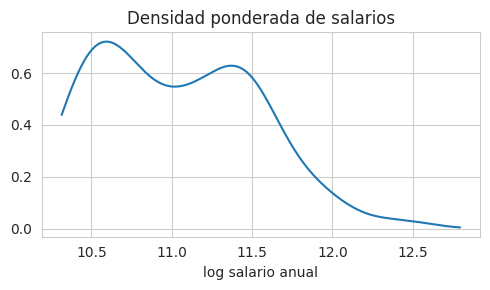

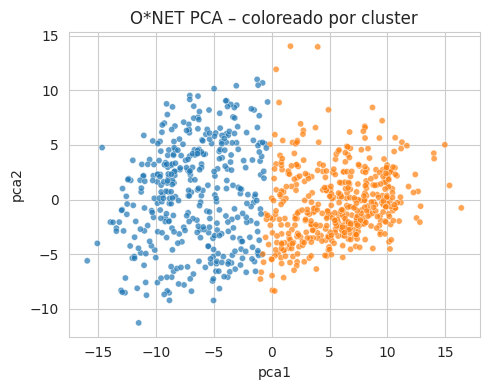

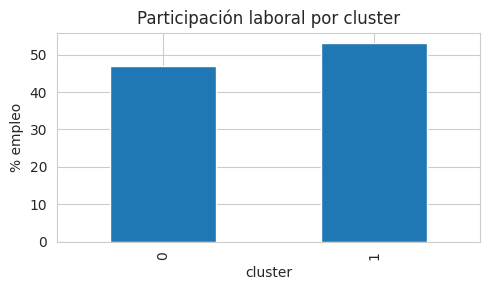

,proxy1,proxy2,proxy3,proxy4,proxy5
0,4.A.3.a.2,4.A.4.a.4,4.A.3.a.1,4.A.1.a.2,4.A.2.b.3
1,4.A.2.b.3,4.A.2.b.6,4.A.4.a.4,4.A.2.b.1,4.A.4.a.2


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 5) Gráficas y tablas clave                                   ║
# ╚════════════════════════════════════════════════════════════╝
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# T1 – quintiles empleo-salario
df_q = df.copy()
df_q["q5"] = pd.qcut(df_q["wage"], 5, labels=range(1,6))
tabla1 = (df_q.groupby("q5", observed=True)
            .agg(emp_total=("tot_emp","sum"),
                 wage_median=("wage","median"))
            .assign(emp_share_pct=lambda d:100*d.emp_total/d.emp_total.sum()))
display(tabla1.style.format({"emp_total":"{:,}",
                             "wage_median":"${:,.0f}",
                             "emp_share_pct":"{:.1f}%"}))

# F1 – densidad kernel ponderada log-wage
w = np.log(df["wage"])
kde = gaussian_kde(w, weights=df["tot_emp"])
xs  = np.linspace(w.min(), w.max(), 400)
plt.figure(figsize=(5,3))
plt.plot(xs, kde(xs)); plt.title("Densidad ponderada de salarios")
plt.xlabel("log salario anual"); plt.tight_layout(); plt.show()

# F2 – PCA biplot (primeras 2 componentes)
plt.figure(figsize=(5,4))
sns.scatterplot(x="pca1", y="pca2", hue="cluster", data=df,
                palette="tab10", s=20, alpha=.7, legend=False)
plt.title("O*NET PCA – coloreado por cluster")
plt.tight_layout(); plt.show()

# F3 – empleo por cluster
emp = (df.groupby("cluster")["tot_emp"].sum()
         .div(df["tot_emp"].sum())*100)
emp.plot(kind="bar", figsize=(5,3))
plt.ylabel("% empleo"); plt.title("Participación laboral por cluster")
plt.tight_layout(); plt.show()

# T2 – carga media de proxies top-5 por cluster (orientativo)
top5 = {}
for cl in sorted(df["cluster"].unique()):
    members = X.loc[df["cluster"]==cl]
    load = members.mean().sort_values(ascending=False)[:5]
    top5[cl] = load.index.str[:30].tolist()
pd.DataFrame.from_dict(top5, orient="index",
                       columns=[f"proxy{i}" for i in range(1,6)])


In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# 6) EXPORTAR l_g, w_g/w_A y dataset limpio                    ║
# ╚════════════════════════════════════════════════════════════╝
# participaciones laborales por cluster
l_g = (df.groupby("cluster")["tot_emp"].sum()
         .div(df["tot_emp"].sum())).to_dict()

# salarios relativos (ponderados por empleo)
def w_weighted(grp):
    vals = grp["wage"].values; wts = grp["tot_emp"].values
    return np.average(vals, weights=wts)

w_abs = df.groupby("cluster").apply(w_weighted)
w_rel = (w_abs / w_abs.iloc[0]).to_dict()   # normaliza al cluster 0 (“A” manual)

targets = {"l_g": l_g, "relative_wages": w_rel, "s_K": 0.40}
import json, pandas as pd

with open("calibration_targets.json","w") as f: json.dump(targets, f, indent=2)
df.to_csv("onet_oews_clustered.csv")

print("✓ guardados: calibration_targets.json  &  onet_oews_clustered.csv")


<ipython-input-20-f3088de664c5>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  w_abs = df.groupby("cluster").apply(w_weighted)


✓ guardados: calibration_targets.json  &  onet_oews_clustered.csv


In [ ]:
import json
import numpy as np
import pandas as pd # Para mostrar la verificación de forma más clara

print("--- Iniciando Calibración Mejorada (Basada en Clusters Empíricos y s_K) ---")

# -------------------------------------
# 1. CARGAR TARGETS EMPÍRICOS DESDE JSON
# -------------------------------------
empirical_targets_loaded = None
try:
    with open("calibration_targets.json", "r") as f:
        empirical_targets_loaded = json.load(f)
    print("Targets empíricos cargados desde calibration_targets.json:")
    print(f"  l_g: {empirical_targets_loaded.get('l_g')}")
    print(f"  relative_wages: {empirical_targets_loaded.get('relative_wages')}")
    print(f"  s_K: {empirical_targets_loaded.get('s_K')}")
    print(f"  (Información adicional en JSON: { {k:v for k,v in empirical_targets_loaded.items() if k not in ['l_g', 'relative_wages', 's_K']} })")

except FileNotFoundError:
    print("ERROR CRÍTICO: No se encontró 'calibration_targets.json'. Ejecuta primero el notebook de clustering.")
    raise
except KeyError as e:
    print(f"ERROR CRÍTICO: Clave {e} faltante en 'calibration_targets.json'. Verifica el archivo.")
    raise
except Exception as e:
    print(f"ERROR CRÍTICO al cargar 'calibration_targets.json': {e}")
    raise

# Extraer nombres de los clusters y el cluster base para normalización
# Asumimos que las claves en l_g y relative_wages son los nombres de los clusters (ej. '0', '1')
# y que el primer cluster en el orden natural es el base para la normalización de salarios.
cluster_names = sorted(empirical_targets_loaded['l_g'].keys())
if not cluster_names:
    print("ERROR CRÍTICO: No se encontraron nombres de cluster en 'l_g' dentro de calibration_targets.json.")
    raise ValueError("Nombres de cluster no encontrados en targets.")

base_cluster_for_norm = cluster_names[0] # Asumir que el primero es la base A_g=1

print(f"\nClusters identificados: {cluster_names}")
print(f"Cluster base para normalización de productividad (A_g=1): '{base_cluster_for_norm}'")

# -------------------------------------
# 2. PARÁMETROS FIJOS DEL MODELO Y DE CALIBRACIÓN
# -------------------------------------
lambda_calib = 1.5
print(f"\nParámetros Fijos del Modelo:")
print(f" - Elasticidad de sustitución (lambda) = {lambda_calib}")

# Productividad del cluster base se normaliza a 1.0
A_base_cluster_val = 1.0
print(f" - Productividad del cluster base (A_{base_cluster_for_norm}) = {A_base_cluster_val} (Normalización)")

# Productividad del Capital/IA (DEBE SER != 1 para que s_K varíe con lambda si se usa en esa fórmula)
A_k_calib = 1.2
print(f" - Productividad del Capital/IA (A_k) = {A_k_calib} (Fijado, crucial para s_K)")

# Oferta de trabajo para cada cluster (L_g) se toma de las participaciones empíricas l_g
L_g_calib = empirical_targets_loaded['l_g']
print(f" - Ofertas de Trabajo (L_g) = l_g empíricas: {L_g_calib}")

# -------------------------------------
# 3. INFERIR CUOTAS DE TAREA BASE (Γ_g, Γ_k) a partir de s_K y l_g
# -------------------------------------
print("\nCalculando Cuotas de Tarea Base (Gammas) consistentes con target s_K...")
Gammas_base_calib = {}
calculation_possible_gamma = True
target_s_K = empirical_targets_loaded['s_K']

try:
    # Gamma_k_base = target_s_K / (A_k**(lambda - 1))
    # Esta fórmula asume que q(x)=1. Si A_k es el parámetro de productividad como en A&R (2022) Eq. 12
    # s_K = (P_k * Gamma_k_hat) / (sum(P_g * Gamma_g_hat) + P_k * Gamma_k_hat)
    # Si P_k = A_k^(lambda-1) y Gamma_k_hat es la medida de tareas, entonces
    # s_K = A_k^(lambda-1) * Gamma_k_tasks / ( sum(A_g^(lambda-1)*Gamma_g_tasks) + A_k^(lambda-1)*Gamma_k_tasks )
    # En el modelo simplificado donde Gamma_k ya es la "cuota efectiva" o "productividad ponderada"
    # como en la Proposición 1 de A&R (2022), s_K = (A_k**(lambda - 1)) * Gamma_k_raw_measure
    # Aquí asumimos que Gamma_k que buscamos es la medida bruta de tareas, y que
    # el A_k**(lambda-1) es el factor de productividad que lo convierte en cuota efectiva.

    productivity_factor_k = A_k_calib**(lambda_calib - 1)
    if productivity_factor_k <= 0:
        print("ERROR CRÍTICO: El término de productividad del capital A_k**(lambda-1) es <= 0.")
        calculation_possible_gamma = False
    else:
        Gamma_k_base_raw_measure = target_s_K / productivity_factor_k
        print(f" - Medida Bruta de Tareas de Capital (Gamma_k_raw_measure) Inferida = {target_s_K:.3f} / ({A_k_calib:.2f}^({lambda_calib:.1f}-1)) = {Gamma_k_base_raw_measure:.4f}")

        if not (0 <= Gamma_k_base_raw_measure < 1): # Gamma_k como medida de tareas debe estar en [0,1)
            print(f"ERROR CRÍTICO: Gamma_k_raw_measure ({Gamma_k_base_raw_measure:.4f}) está fuera del rango [0, 1). Revisa target s_K o A_k, lambda.")
            calculation_possible_gamma = False
        else:
            Gammas_base_calib['Gamma_k'] = Gamma_k_base_raw_measure # Esta es la medida de tareas que hace IA

            Gamma_L_total_raw_measure = 1.0 - Gamma_k_base_raw_measure
            print(f" - Medida Bruta Total de Tareas Laborales = 1 - {Gamma_k_base_raw_measure:.4f} = {Gamma_L_total_raw_measure:.4f}")

            if Gamma_L_total_raw_measure < 0:
                print("ERROR CRÍTICO: Medida Bruta Total de Tareas Laborales es negativa.")
                calculation_possible_gamma = False
            else:
                # Distribuir la medida bruta de tareas laborales entre los clusters según l_g
                # Asumimos que l_g es una buena proxy de la proporción de tareas que hace cada tipo de trabajo
                # del total de tareas laborales.
                sum_l_g = sum(L_g_calib.values())
                if sum_l_g <= 0 or not np.isclose(sum_l_g, 1.0): # l_g debe sumar a 1
                    print(f"ERROR CRÍTICO: Suma de l_g ({sum_l_g:.4f}) no es 1.0 o es inválida.")
                    calculation_possible_gamma = False
                else:
                    for g_cluster_name in cluster_names:
                        l_g_val = L_g_calib[g_cluster_name]
                        Gamma_g_raw_measure = Gamma_L_total_raw_measure * l_g_val # l_g_val ya es una proporción
                        Gammas_base_calib[f'Gamma_{g_cluster_name}'] = Gamma_g_raw_measure
                        print(f"   - Gamma_{g_cluster_name}_raw_measure = {Gamma_L_total_raw_measure:.4f} * {l_g_val:.4f} = {Gamma_g_raw_measure:.4f}")

                    sum_gammas_final = sum(Gammas_base_calib.values())
                    if not np.isclose(sum_gammas_final, 1.0):
                        print(f"ADVERTENCIA: La suma de todas las Gammas_raw_measure base calculadas ({sum_gammas_final:.4f}) no es 1.0.")
                    else:
                        print(" - Suma de Gammas_raw_measure base es 1.0. ¡Correcto!")
except Exception as e:
    print(f"ERROR CRÍTICO calculando Gammas Base: {e}")
    calculation_possible_gamma = False

if not calculation_possible_gamma:
    raise ValueError("No se pudieron calcular las Gammas base. Revisa los errores.")

# -------------------------------------
# 4. CÁLCULO DIRECTO de Productividades Relativas A_g
# -------------------------------------
# Fórmula derivada de w_g/w_base = [ (A_g * L_base / (A_base * L_g)) * (Gamma_g / Gamma_base) ] ^ (1/lambda)
# Entonces A_g = A_base * (target_wg_rel) ^ lambda * (L_g / L_base) * (Gamma_base / Gamma_g)
# Corregido: A_g = A_base_val * [ target_wg_rel * (L_g_val / L_base_val)**(1/lambda_calib) * (Gamma_base_val / Gamma_g_val)**(1/lambda_calib) ]**(lambda_calib / (lambda_calib - 1))
# Si A_base_val = 1: A_g = [ target_wg_rel * (L_g_val / L_base_val)**(1/lambda_calib) * (Gamma_base_val / Gamma_g_val)**(1/lambda_calib) ]**(lambda_calib / (lambda_calib - 1))

print(f"\nCalculando productividades relativas A_g (respecto a A_{base_cluster_for_norm}={A_base_cluster_val})...")
calibrated_A_params = {base_cluster_for_norm: A_base_cluster_val}
calculation_possible_A = True

L_base_val = L_g_calib.get(base_cluster_for_norm)
Gamma_base_val = Gammas_base_calib.get(f'Gamma_{base_cluster_for_norm}')

if L_base_val is None or L_base_val <= 0 or Gamma_base_val is None or Gamma_base_val < 0: # Gamma puede ser 0 si l_g es 0
    print(f"ERROR CRÍTICO: L_{base_cluster_for_norm} ({L_base_val}) o Gamma_{base_cluster_for_norm} ({Gamma_base_val}) no son válidos.")
    calculation_possible_A = False

if calculation_possible_A:
    if lambda_calib == 1:
        print("ERROR CRÍTICO: lambda no puede ser 1 para la fórmula de A_g.")
        calculation_possible_A = False
    else:
        lambda_term_exponent = lambda_calib / (lambda_calib - 1)

        for g_cluster_name in cluster_names:
            if g_cluster_name == base_cluster_for_norm:
                continue # Ya está fijado

            target_wg_rel = empirical_targets_loaded['relative_wages'].get(g_cluster_name)
            L_g_val = L_g_calib.get(g_cluster_name)
            Gamma_g_val = Gammas_base_calib.get(f'Gamma_{g_cluster_name}')

            if target_wg_rel is None or L_g_val is None or L_g_val < 0 or Gamma_g_val is None or Gamma_g_val < 0: # L y Gamma pueden ser 0 si no hay empleo/tareas
                print(f"ERROR: Faltan datos válidos para A_{g_cluster_name}. Target RelWage={target_wg_rel}, L={L_g_val}, Gamma={Gamma_g_val}")
                calibrated_A_params[g_cluster_name] = np.nan
                continue

            if L_g_val == 0 or Gamma_g_val == 0: # Si no hay trabajo o tareas, la productividad es irrelevante o indefinida
                print(f"INFO: L_{g_cluster_name} o Gamma_{g_cluster_name} es cero. A_{g_cluster_name} se establece como NaN o 0.")
                calibrated_A_params[g_cluster_name] = 0.0 # O np.nan, dependiendo de cómo se maneje después
                continue

            try:
                l_ratio_term = (L_g_val / L_base_val)**(1 / lambda_calib)
                gamma_ratio_term = (Gamma_base_val / Gamma_g_val)**(1 / lambda_calib) # Gamma_base / Gamma_g
                inner_term = target_wg_rel * l_ratio_term * gamma_ratio_term

                if inner_term < 0 and (lambda_term_exponent * 10) % 10 != 0 : # Raíz par de negativo
                     print(f"Advertencia: Término interno para A_{g_cluster_name} es negativo ({inner_term:.3f}) y el exponente no es entero. A_g podría ser complejo. Se usará NaN.")
                     A_g_val = np.nan
                else:
                     A_g_val = A_base_cluster_val * (inner_term**lambda_term_exponent)

                calibrated_A_params[g_cluster_name] = A_g_val
                print(f" - A_{g_cluster_name} calculado = {A_g_val:.4f}")
            except ZeroDivisionError:
                print(f"ERROR: División por cero al calcular A_{g_cluster_name} (L_base_val={L_base_val}, Gamma_g_val={Gamma_g_val}). A_{g_cluster_name} será NaN.")
                calibrated_A_params[g_cluster_name] = np.nan
            except Exception as e:
                print(f"ERROR calculando A_{g_cluster_name}: {e}")
                calibrated_A_params[g_cluster_name] = np.nan
else:
    print("Cálculo de A_g omitido debido a errores previos.")

# -------------------------------------
# 5. CONSTRUIR DICCIONARIO DE PARÁMETROS CALIBRADOS
# -------------------------------------
print("\n--- PARÁMETROS CALIBRADOS FINALES (Enfoque s_K con Clusters) ---")
calibrated_params_final = {'lambda_': lambda_calib, 'A_k': A_k_calib}

for g_cluster_name in cluster_names:
    calibrated_params_final[f'L_{g_cluster_name}'] = L_g_calib.get(g_cluster_name, 0.0)
    calibrated_params_final[f'A_{g_cluster_name}'] = calibrated_A_params.get(g_cluster_name, np.nan)

# Añadir rangos de tareas si son necesarios para otras funciones (aunque este script no los usa para calibrar A_g)
# Estos son placeholders y no afectan la calibración de A_g aquí.
# Si `calculate_task_shares` los necesita, deben estar definidos.
calibrated_params_final.update({
    'TR_range': (0.0, 0.25), 'TA_range': (0.25, 0.5),
    'TS_range': (0.5, 0.75), 'TJ_range': (0.75, 1.0),
})


params_complete_final = calculation_possible_A and \
                       (not any(pd.isna(v) for k, v in calibrated_params_final.items() if k.startswith('A_') and k != 'A_k'))

if params_complete_final:
    print("Diccionario `calibrated_params_final` (listo para usar en simulaciones):")
    for key, value in calibrated_params_final.items():
        if isinstance(value, float): print(f"  '{key}': {value:.4f}")
        else: print(f"  '{key}': {value}")

    print("\nCuotas de Tarea Base (Gammas_raw_measure) calculadas:")
    for key, value in Gammas_base_calib.items():
         print(f"  '{key}': {value:.4f}")
else:
    print("Diccionario `calibrated_params_final` no se pudo completar debido a errores en el cálculo de A_g o Gammas.")

# -------------------------------------
# 6. VERIFICACIÓN (MUY RECOMENDADO)
# -------------------------------------
# Usar los parámetros calibrados para resolver el modelo base y
# verificar si los salarios relativos Y s_K coinciden con los targets.
# ¡¡ASEGÚRATE DE QUE LAS FUNCIONES solve_equilibrium y (si aplica) calculate_task_shares
# ESTÉN DEFINIDAS EN TU COLAB Y ADAPTADAS PARA LOS NUEVOS CLUSTERS!!

functions_exist_for_verification = False
try:
    # Intenta una llamada dummy a solve_equilibrium para ver si existe y está adaptada
    # Esta es una llamada muy simplificada, solo para chequear
    _ = solve_equilibrium(
        Gammas={'Gamma_k': 0.3, **{f'Gamma_{cn}': 0.7/len(cluster_names) for cn in cluster_names}},
        params={'lambda_': 1.5, 'A_k': 1.2,
                **{f'L_{cn}': 0.5 for cn in cluster_names},
                **{f'A_{cn}': 1.0 for cn in cluster_names}}
    )
    functions_exist_for_verification = True
    print("\nFunción 'solve_equilibrium' parece estar definida y adaptada.")
except NameError:
    print("\nADVERTENCIA: La función 'solve_equilibrium' no está definida. No se puede realizar la verificación.")
except Exception as e_verify_func:
    print(f"\nADVERTENCIA: Posible problema con 'solve_equilibrium' o su adaptación: {e_verify_func}. No se puede realizar la verificación.")


if functions_exist_for_verification and params_complete_final and calculation_possible_gamma:
    print("\n--- Verificación: Resolviendo modelo BASE con parámetros y Gammas calibradas ---")

    try:
        verification_results = solve_equilibrium(Gammas_base_calib, calibrated_params_final)

        model_rel_wages_verif = {}
        w_base_verif_val = verification_results.get(f'w_{base_cluster_for_norm}')

        if w_base_verif_val is not None and w_base_verif_val > 0:
            for g_cluster_name in cluster_names:
                wg_val = verification_results.get(f'w_{g_cluster_name}')
                if wg_val is not None:
                    model_rel_wages_verif[g_cluster_name] = wg_val / w_base_verif_val
                else:
                    model_rel_wages_verif[g_cluster_name] = np.nan

            print("\nComparación Targets vs Modelo (Salarios Relativos w_g/w_base_cluster):")
            results_comparison = []
            for g_cluster_name in cluster_names:
                target = empirical_targets_loaded['relative_wages'].get(g_cluster_name, np.nan)
                model_val = model_rel_wages_verif.get(g_cluster_name, np.nan)
                diff = model_val - target if pd.notna(target) and pd.notna(model_val) else np.nan
                results_comparison.append({
                    'Cluster': g_cluster_name,
                    'Target Empírico': target,
                    'Modelo Calibrado': model_val,
                    'Diferencia': diff
                })
            print(pd.DataFrame(results_comparison).to_string(index=False, float_format='{:.3f}'.format))

            model_sK_verif = verification_results.get('s_K')
            target_sK_verif = empirical_targets_loaded['s_K']
            if model_sK_verif is not None:
                diff_sK_verif = model_sK_verif - target_sK_verif
                print(f"\nComparación s_K:")
                print(f" - Target Empírico: {target_sK_verif:.4f}")
                print(f" - Modelo Base Calibrado: {model_sK_verif:.4f}")
                print(f" - Diferencia: {diff_sK_verif:.4g} (¡Debería ser cercano a cero!)")
            else:
                print("Error en verificación: s_K no calculado por el modelo.")
        else:
            print(f"Error en verificación: Salario del cluster base w_{base_cluster_for_norm} es cero o inválido ({w_base_verif_val}).")
            print("Resultados completos de la verificación: ", verification_results)

    except Exception as e_verif:
        print(f"Error CRÍTICO durante la verificación: {e_verif}")
        import traceback
        traceback.print_exc()
else:
    print("\n--- Verificación OMITIDA ---")
    if not functions_exist_for_verification: print("  Causa: Función 'solve_equilibrium' no definida o no adaptada.")
    if not params_complete_final: print("  Causa: No se pudieron calcular todos los parámetros A_g necesarios.")
    if not calculation_possible_gamma: print("  Causa: No se pudieron calcular las Gammas base.")

print("\n--- FIN DEL SCRIPT DE CALIBRACIÓN MEJORADA ---")
if 'params_complete_final' in locals() and params_complete_final:
    print("\n¡Calibración completada! Los diccionarios `calibrated_params_final` y `Gammas_base_calib` están listos.")
    print("Recuerda que las funciones `solve_equilibrium` y `calculate_task_shares` deben estar adaptadas en tu Colab para usar estos parámetros con los nuevos clusters.")
else:
    print("\nLa calibración no pudo completarse debido a errores. Revisa los mensajes.")